In [25]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import ast
import torch
import pickle
import numpy as np


## Training curves

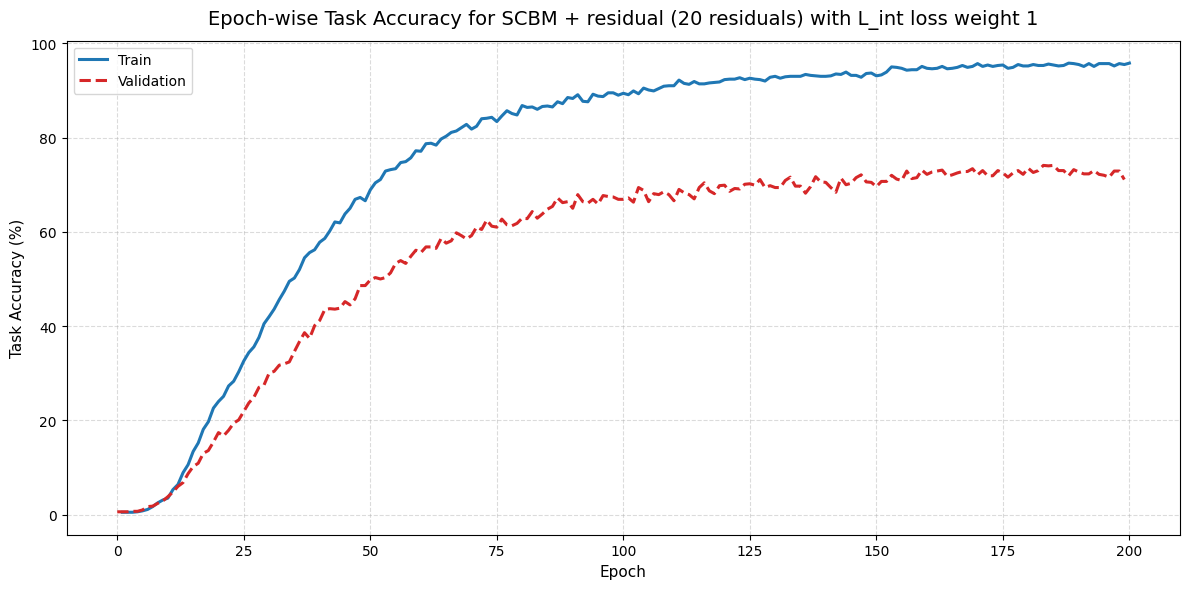

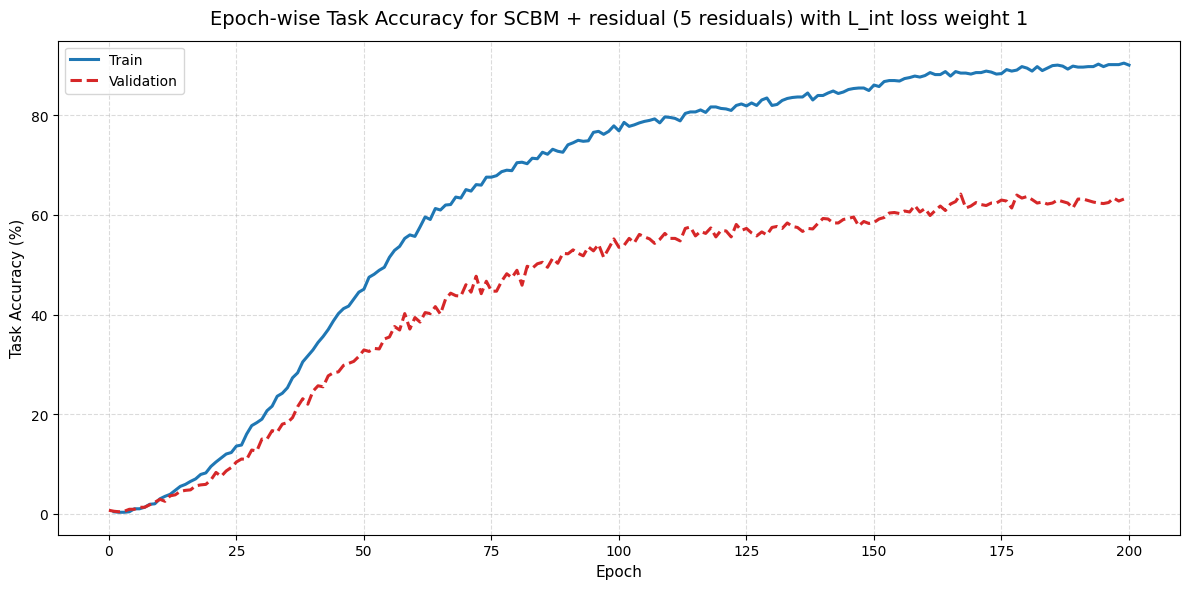

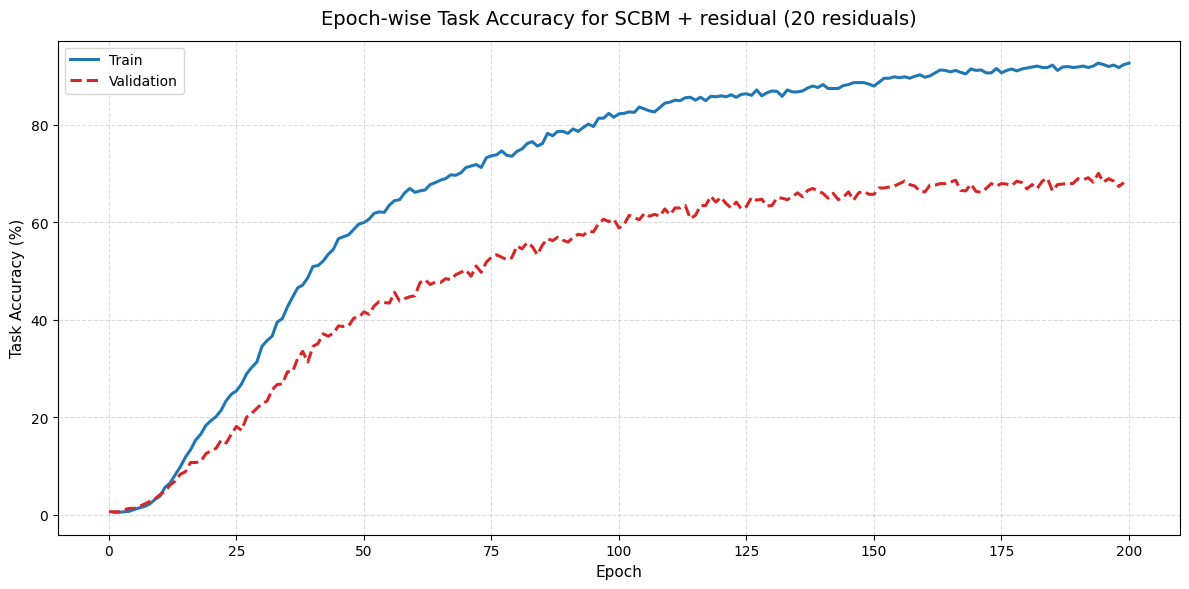

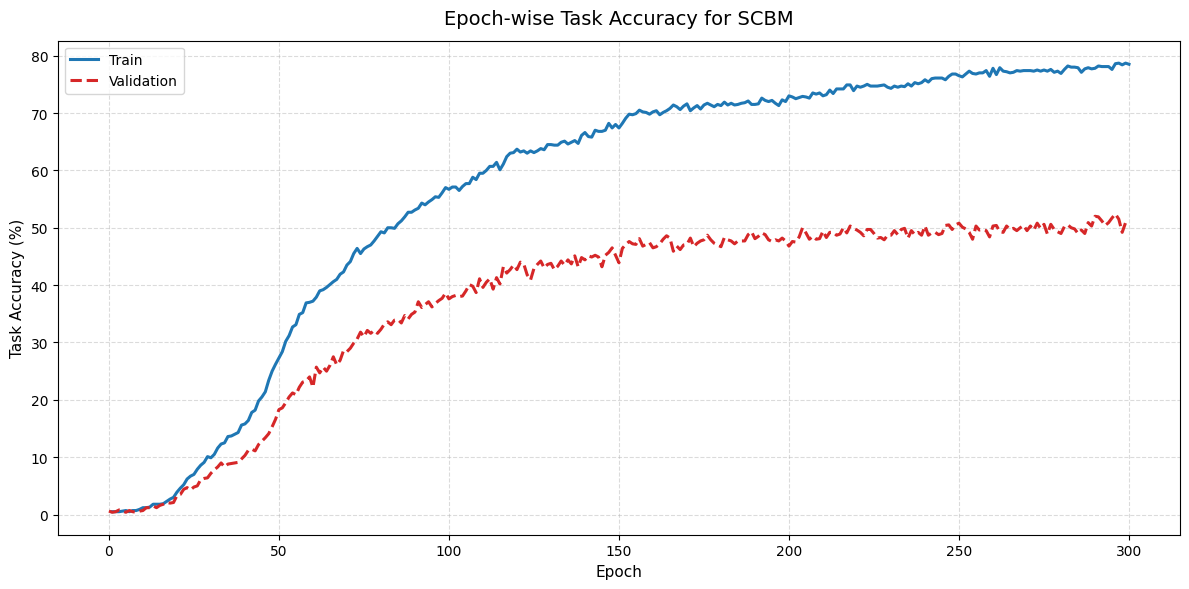

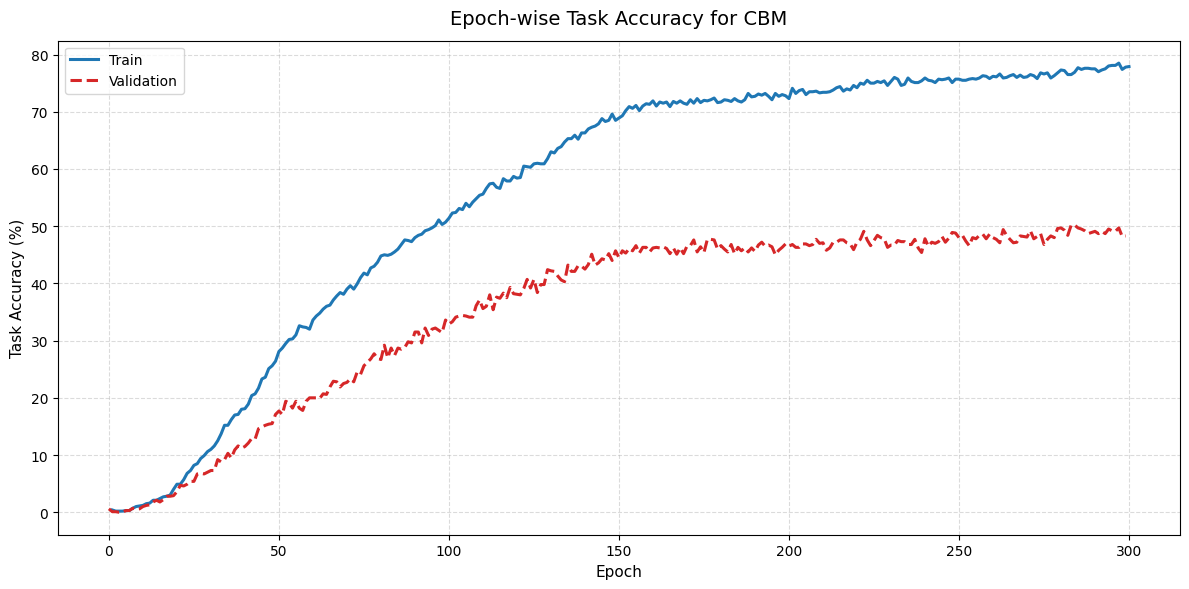

In [26]:
def extract_epoch_accuracies(full_model_path, split="Train"):
    epoch_accuracies = []
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Epoch" in line and "y_accuracy" in line and "c_accuracy" in line and split in line:
                epoch_num = re.findall(r"Epoch\s*(\d+)", line)[0]
                y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", line)[0]
                c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", line)[0]
                epoch_accuracies.append((int(epoch_num), float(y_accuracy) * 100, float(c_accuracy) * 100))
    return epoch_accuracies

scbm_model_dir = os.path.join("experiments", "scbm", "TravelingBirds")
scbm_res_model_dir = os.path.join("experiments", "scbm_residual", "TravelingBirds")
cbm_model_dir = os.path.join("experiments", "cbm", "TravelingBirds")

model_dirs_titles = [(scbm_res_model_dir,
                      "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed",
                      "SCBM + residual (20 residuals) with L_int loss weight 1"),
                    (scbm_res_model_dir, 
                      "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", 
                      "SCBM + residual (5 residuals) with L_int loss weight 1"),
                     (scbm_res_model_dir,
                      "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e",
                      "SCBM + residual (20 residuals)"),
                     (scbm_model_dir,
                      "Mateo_025_2026-08-10_17-06-22_5b4d7",
                      "SCBM"),
                     (cbm_model_dir,
                      "Mateo_025_2026-08-10_17-07-25_84e08",
                      "CBM")]


for root_model_dir, model_name, title in model_dirs_titles:
    full_model_path = os.path.join(root_model_dir, model_name)
    train_accuracies = extract_epoch_accuracies(full_model_path, split="Train")
    val_accuracies = extract_epoch_accuracies(full_model_path, split="Validation")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        [epoch[0] for epoch in train_accuracies],
        [epoch[1] for epoch in train_accuracies],
        label="Train",
        color="#1f77b4",
        linewidth=2.2,
        markersize=6,
    )
    ax.plot(
        [epoch[0] for epoch in val_accuracies],
        [epoch[1] for epoch in val_accuracies],
        label="Validation",
        color="#d62728",
        linestyle="--",
        linewidth=2.2,
        markersize=6,
    )
    ax.set_title(f"Epoch-wise Task Accuracy for {title}", fontsize=14, pad=12)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Task Accuracy (%)", fontsize=11)
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()
    


## Interventions 

In [27]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="TravelingBirds", return_c_auroc=False, return_auroc=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []

    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

In [28]:
def retrieve_acc_from_log(model_dir, linear_model=False):

                with open(os.path.join(model_dir, "log.txt"), "r") as f:
                    lines = f.readlines()
                    test_line = lines[-1]
                    if linear_model:
                        y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = None
                        c_auc = None
                    else:
                        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
                    y_accuracy = float(y_accuracy) * 100
                    if c_accuracy is not None:
                        c_accuracy = float(c_accuracy) * 100
                    return y_accuracy, c_accuracy, c_auc

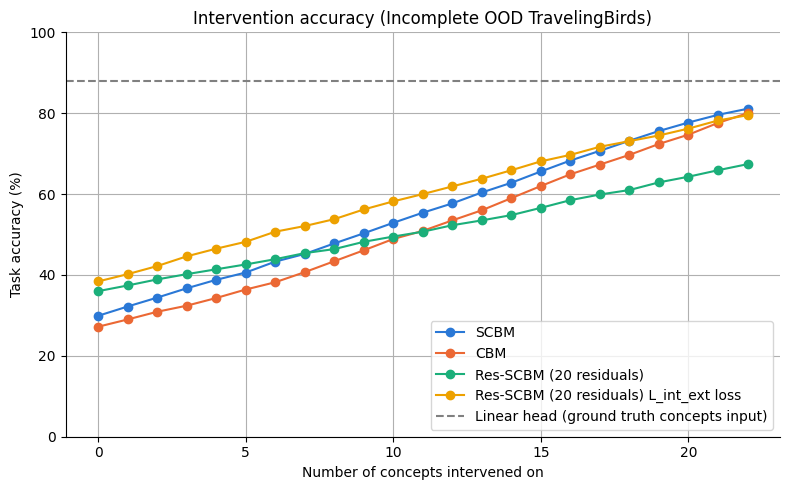

In [ ]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [("SCBM", "Mateo_025_2026-08-10_17-06-22_5b4d7", "scbm"),
          ("Hard CBM", "Mateo_025_2026-08-10_17-07-25_84e08", "cbm"),
          ("Res-SCBM (20 residuals)", "Mateo_025_fixed_residuals_20_2026-08-10_17-06-05_7679e", "scbm_residual"),
          ("Res-SCBM (20 residuals) L_int_ext loss", "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-08-11_12-01-55_9dbed", "scbm_residual"),
          #("Res-SCBM (5 residuals) L_int_ext", "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-08-10_17-06-05_57592", "scbm_residual")
          ]

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 5))
for (label, model_dir, model_type), color in zip(models, colors):
    concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
        model_dir, model_type=model_type
    )
    ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

# Linear head ground truth concepts input
y_acc_mateo_075 = retrieve_acc_from_log(os.path.join("experiments", "linear_head", "CUB", "Mateo_025_2026-05-06_12-41-45_15c1b"), linear_model=True)[0]
ax.axhline(y=y_acc_mateo_075, color="gray", linestyle="--", label="Linear head (ground truth concepts input)")

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("Intervention accuracy (Incomplete OOD TravelingBirds)")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()